# Inspect Sharded Dataset

This notebook provides tools to inspect shards from the processed dataset:
1. **Schema Validation**: Verify all required fields are present
2. **Synchronization Check**: Verify frame timestamps are within fbank bounds
3. **Visualization**: Frame timestamps marked on spectrograms with slice windows

In [22]:
import torch
import torch.nn.functional as F
import io
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [16, 8]

In [31]:
# --- Configuration ---
SHARD_PATH = "/storage/slurm/hunecke/fakesync/data/voxceleb2/preprocessed/shards_train/shard_0000.pt"  # Update to your shard path
TARGET_LENGTH = 42  # fbank slice length for each frame
NUM_SAMPLES_VIZ = 3

In [32]:
def load_shard(path):
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return []
    print(f"Loading shard from {path}...")
    data = torch.load(path, map_location="cpu")
    print(f"Loaded {len(data)} samples.")
    return data

In [33]:
def validate_schema(sample):
    """Validate that sample has all required fields for sync."""
    required = [
        "video_id",
        "fbank",
        "fbank_length",
        "images",
        "frame_indices",
        "frame_timestamps_ms",
        "video_fps",
        "video_duration_ms",
        "valid",
    ]

    missing = [f for f in required if f not in sample]
    if missing:
        print(f"⚠️ Missing fields: {missing}")
        return False
    print("✅ Schema valid - all required fields present")
    return True

In [34]:
def check_sync(sample):
    """CRITICAL: Verify frame timestamps are within fbank bounds."""
    fbank_length = sample.get("fbank_length", sample["fbank"].shape[0])
    fbank_duration_ms = fbank_length * 10

    timestamps = sample.get("frame_timestamps_ms", [])
    if not timestamps:
        print("⚠️ No timestamps found (legacy shard)")
        return False

    max_ts = max(timestamps)

    print(f"Fbank Length: {fbank_length} frames ({fbank_duration_ms}ms)")
    print(f"Max Timestamp: {max_ts:.1f}ms")

    if max_ts > fbank_duration_ms:
        print(f"❌ SYNC FAILURE: Frame at {max_ts}ms exceeds fbank duration {fbank_duration_ms}ms")
        return False

    print("✅ SYNC OK: All frames within fbank bounds")
    return True

In [35]:
def slice_fbank_at_timestamp(full_fbank, fbank_length, timestamp_ms, target_length):
    """Slice fbank centered at timestamp with edge padding."""
    center = int(timestamp_ms / 10)
    half = target_length // 2
    start = center - half
    end = start + target_length

    pad_left = max(0, -start)
    pad_right = max(0, end - fbank_length)

    if start < 0:
        start = 0
    if end > fbank_length:
        end = fbank_length

    segment = full_fbank[start:end, :]
    if pad_left > 0 or pad_right > 0:
        segment = F.pad(segment, (0, 0, pad_left, pad_right))

    return segment, center, pad_left, pad_right

In [47]:
def visualize_with_timestamps(sample, target_length=42):
    """Visualize spectrogram with frame timestamp markers and slice windows."""
    video_id = sample.get("video_id", "Unknown")
    fbank = sample["fbank"].float()
    fbank_length = sample.get("fbank_length", fbank.shape[0])
    timestamps = sample.get("frame_timestamps_ms", [])
    frame_indices = sample.get("frame_indices", [])
    images_bytes = sample["images"]

    # Normalize fbank for visualization
    fbank_vis = fbank[:fbank_length, :]
    if fbank_vis.max() > fbank_vis.min():
        fbank_vis = (fbank_vis - fbank_vis.min()) / (fbank_vis.max() - fbank_vis.min())

    fig = plt.figure(figsize=(20, 14))

    # 1. Full Spectrogram with frame markers and slice windows
    ax1 = plt.subplot2grid((4, 8), (0, 0), colspan=8, rowspan=1)
    im1 = ax1.imshow(fbank_vis.t().numpy(), origin="lower", aspect="auto", cmap="inferno")
    # remove grid but not axis
    ax1.grid(False)
    plt.colorbar(im1, ax=ax1)

    # Add frame markers and slice windows
    for i, ts in enumerate(timestamps):
        frame_pos = int(ts / 10)
        start = frame_pos - target_length // 2
        end = frame_pos + target_length // 2

        color = "cyan" if i % 2 == 0 else "lime"
        ax1.axvline(x=frame_pos, color=color, alpha=0.7, linewidth=1.5)
        ax1.axvspan(max(0, start), min(fbank_length, end), alpha=0.2, color=color)
        ax1.text(frame_pos, fbank_vis.shape[1] + 2, f"F{i}", fontsize=7, color=color, ha="center", fontweight="bold")

    # Mark fbank end
    ax1.axvline(x=fbank_length, color="red", alpha=0.8, linewidth=2, linestyle="--", label="Fbank End")
    ax1.set_title(f"Full Spectrogram ({fbank_length} frames = {fbank_length*10}ms) | Video: {video_id}")
    ax1.set_xlabel("Time (10ms frames)")
    ax1.set_ylabel("Mel Bins")
    ax1.legend(loc="upper right")

    # 2. Sliced spectrograms for first 4 frames
    for i in range(min(4, len(timestamps))):
        ax = plt.subplot2grid((4, 8), (1, i * 2), colspan=2, rowspan=1)
        segment, center, pad_l, pad_r = slice_fbank_at_timestamp(fbank, fbank_length, timestamps[i], target_length)

        seg_vis = segment
        if seg_vis.max() > seg_vis.min():
            seg_vis = (seg_vis - seg_vis.min()) / (seg_vis.max() - seg_vis.min())

        ax.imshow(seg_vis.t().numpy(), origin="lower", aspect="auto", cmap="inferno")
        # remove grid but not axis
        ax.grid(False)
        ax.axvline(x=target_length // 2, color="white", alpha=0.8, linestyle="--")
        ax.set_title(f"Frame {i} @ {timestamps[i]:.0f}ms\npad_l={pad_l}, pad_r={pad_r}", fontsize=9)

    # 3. Video frames
    for i in range(16):
        row = 2 + i // 8
        col = i % 8
        ax = plt.subplot2grid((4, 8), (row, col))

        img = Image.open(io.BytesIO(images_bytes[i]))
        ax.imshow(img)
        ax.axis("off")
        ts_label = f"{timestamps[i]:.0f}ms" if timestamps else ""
        ax.set_title(f"F{i} {ts_label}", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print sync info
    print(f"\n--- Timestamp Info ---")
    for i, (idx, ts) in enumerate(zip(frame_indices, timestamps)):
        _, center, pad_l, pad_r = slice_fbank_at_timestamp(fbank, fbank_length, ts, target_length)
        print(f"Frame {i:2d}: idx={idx:3d}, ts={ts:7.1f}ms, center={center:4d}, pad_l={pad_l}, pad_r={pad_r}")

Loading shard from /storage/slurm/hunecke/fakesync/data/voxceleb2/preprocessed/shards_train/shard_0000.pt...
Loaded 3969 samples.

=== Schema Validation ===
✅ Schema valid - all required fields present

=== Sync Check ===
Fbank Length: 427 frames (4270ms)
Max Timestamp: 4000.0ms
✅ SYNC OK: All frames within fbank bounds

=== Visualization ===


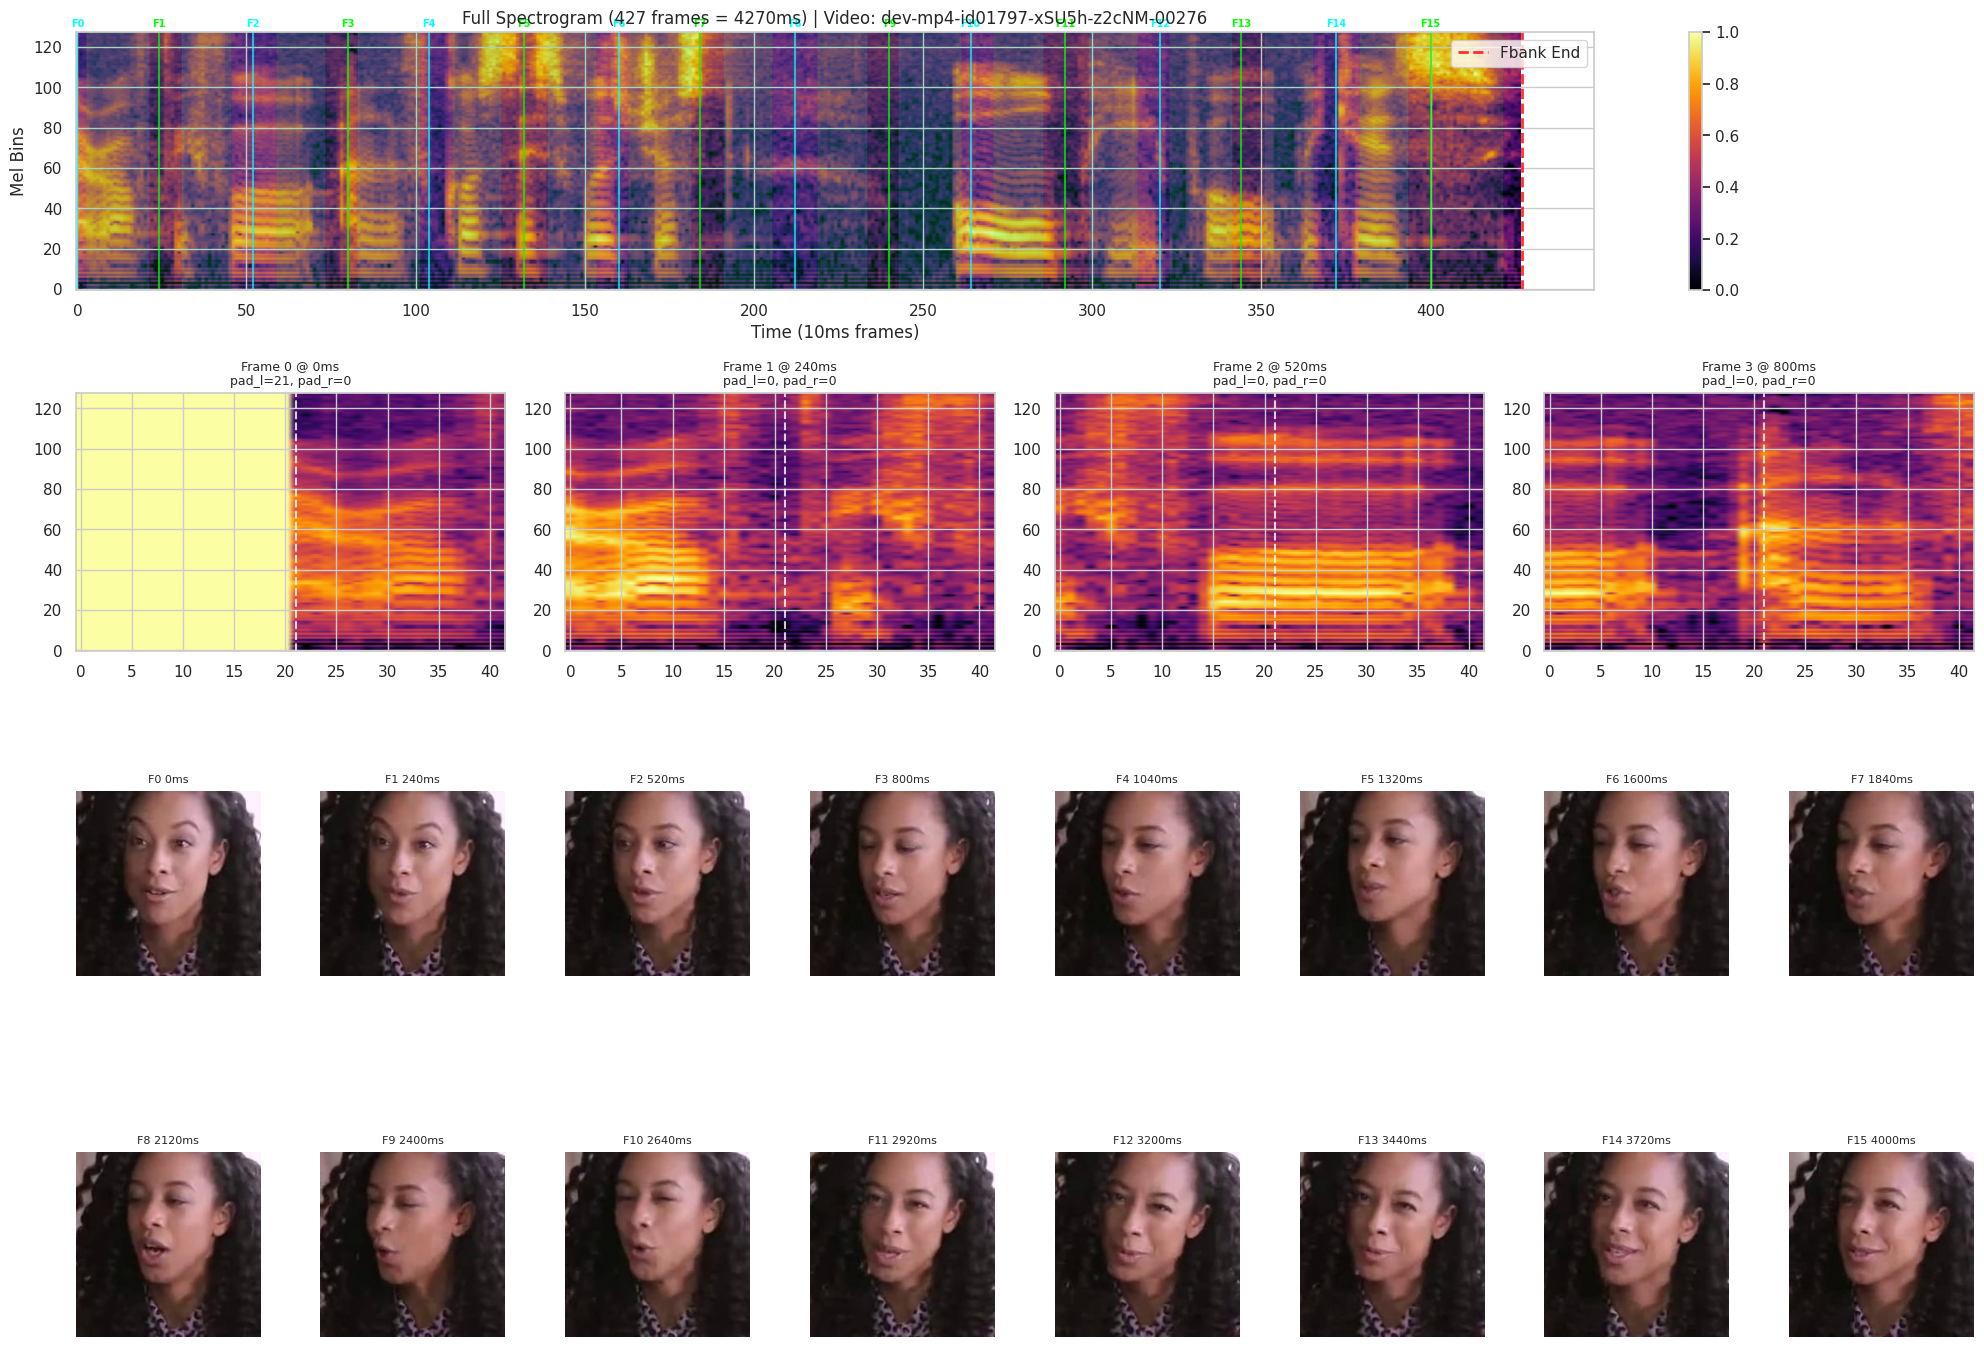


--- Timestamp Info ---
Frame  0: idx=  0, ts=    0.0ms, center=   0, pad_l=21, pad_r=0
Frame  1: idx=  6, ts=  240.0ms, center=  24, pad_l=0, pad_r=0
Frame  2: idx= 13, ts=  520.0ms, center=  52, pad_l=0, pad_r=0
Frame  3: idx= 20, ts=  800.0ms, center=  80, pad_l=0, pad_r=0
Frame  4: idx= 26, ts= 1040.0ms, center= 104, pad_l=0, pad_r=0
Frame  5: idx= 33, ts= 1320.0ms, center= 132, pad_l=0, pad_r=0
Frame  6: idx= 40, ts= 1600.0ms, center= 160, pad_l=0, pad_r=0
Frame  7: idx= 46, ts= 1840.0ms, center= 184, pad_l=0, pad_r=0
Frame  8: idx= 53, ts= 2120.0ms, center= 212, pad_l=0, pad_r=0
Frame  9: idx= 60, ts= 2400.0ms, center= 240, pad_l=0, pad_r=0
Frame 10: idx= 66, ts= 2640.0ms, center= 264, pad_l=0, pad_r=0
Frame 11: idx= 73, ts= 2920.0ms, center= 292, pad_l=0, pad_r=0
Frame 12: idx= 80, ts= 3200.0ms, center= 320, pad_l=0, pad_r=0
Frame 13: idx= 86, ts= 3440.0ms, center= 344, pad_l=0, pad_r=0
Frame 14: idx= 93, ts= 3720.0ms, center= 372, pad_l=0, pad_r=0
Frame 15: idx=100, ts= 4000.0m

In [37]:
# --- Main Execution ---
data = load_shard(SHARD_PATH)

if data:
    sample = data[0]

    print("\n=== Schema Validation ===")
    validate_schema(sample)

    print("\n=== Sync Check ===")
    check_sync(sample)

    print("\n=== Visualization ===")
    visualize_with_timestamps(sample, TARGET_LENGTH)

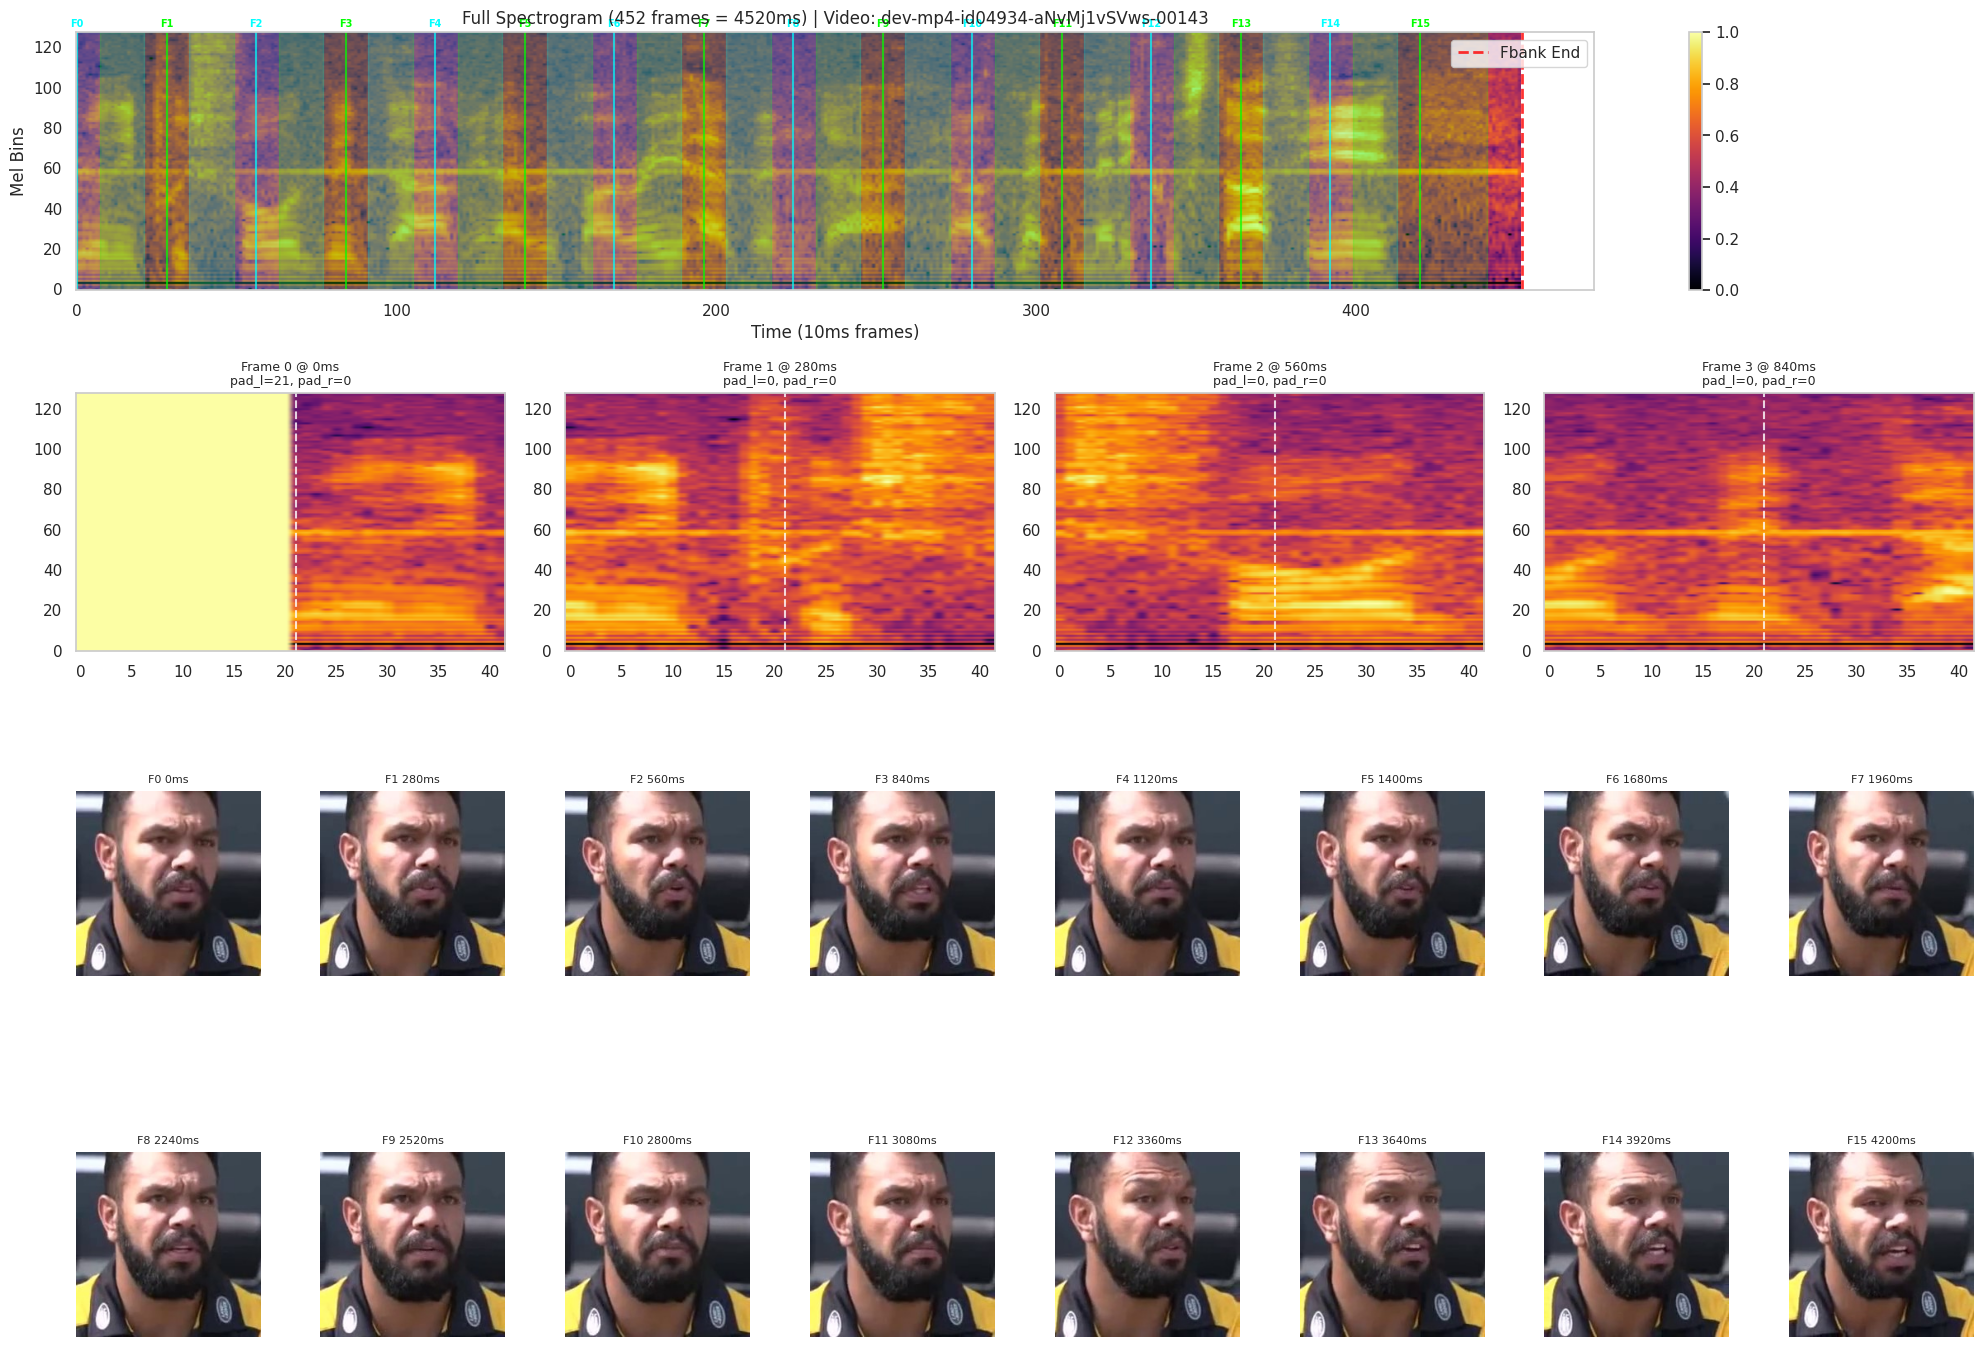


--- Timestamp Info ---
Frame  0: idx=  0, ts=    0.0ms, center=   0, pad_l=21, pad_r=0
Frame  1: idx=  7, ts=  280.0ms, center=  28, pad_l=0, pad_r=0
Frame  2: idx= 14, ts=  560.0ms, center=  56, pad_l=0, pad_r=0
Frame  3: idx= 21, ts=  840.0ms, center=  84, pad_l=0, pad_r=0
Frame  4: idx= 28, ts= 1120.0ms, center= 112, pad_l=0, pad_r=0
Frame  5: idx= 35, ts= 1400.0ms, center= 140, pad_l=0, pad_r=0
Frame  6: idx= 42, ts= 1680.0ms, center= 168, pad_l=0, pad_r=0
Frame  7: idx= 49, ts= 1960.0ms, center= 196, pad_l=0, pad_r=0
Frame  8: idx= 56, ts= 2240.0ms, center= 224, pad_l=0, pad_r=0
Frame  9: idx= 63, ts= 2520.0ms, center= 252, pad_l=0, pad_r=0
Frame 10: idx= 70, ts= 2800.0ms, center= 280, pad_l=0, pad_r=0
Frame 11: idx= 77, ts= 3080.0ms, center= 308, pad_l=0, pad_r=0
Frame 12: idx= 84, ts= 3360.0ms, center= 336, pad_l=0, pad_r=0
Frame 13: idx= 91, ts= 3640.0ms, center= 364, pad_l=0, pad_r=0
Frame 14: idx= 98, ts= 3920.0ms, center= 392, pad_l=0, pad_r=0
Frame 15: idx=105, ts= 4200.0m

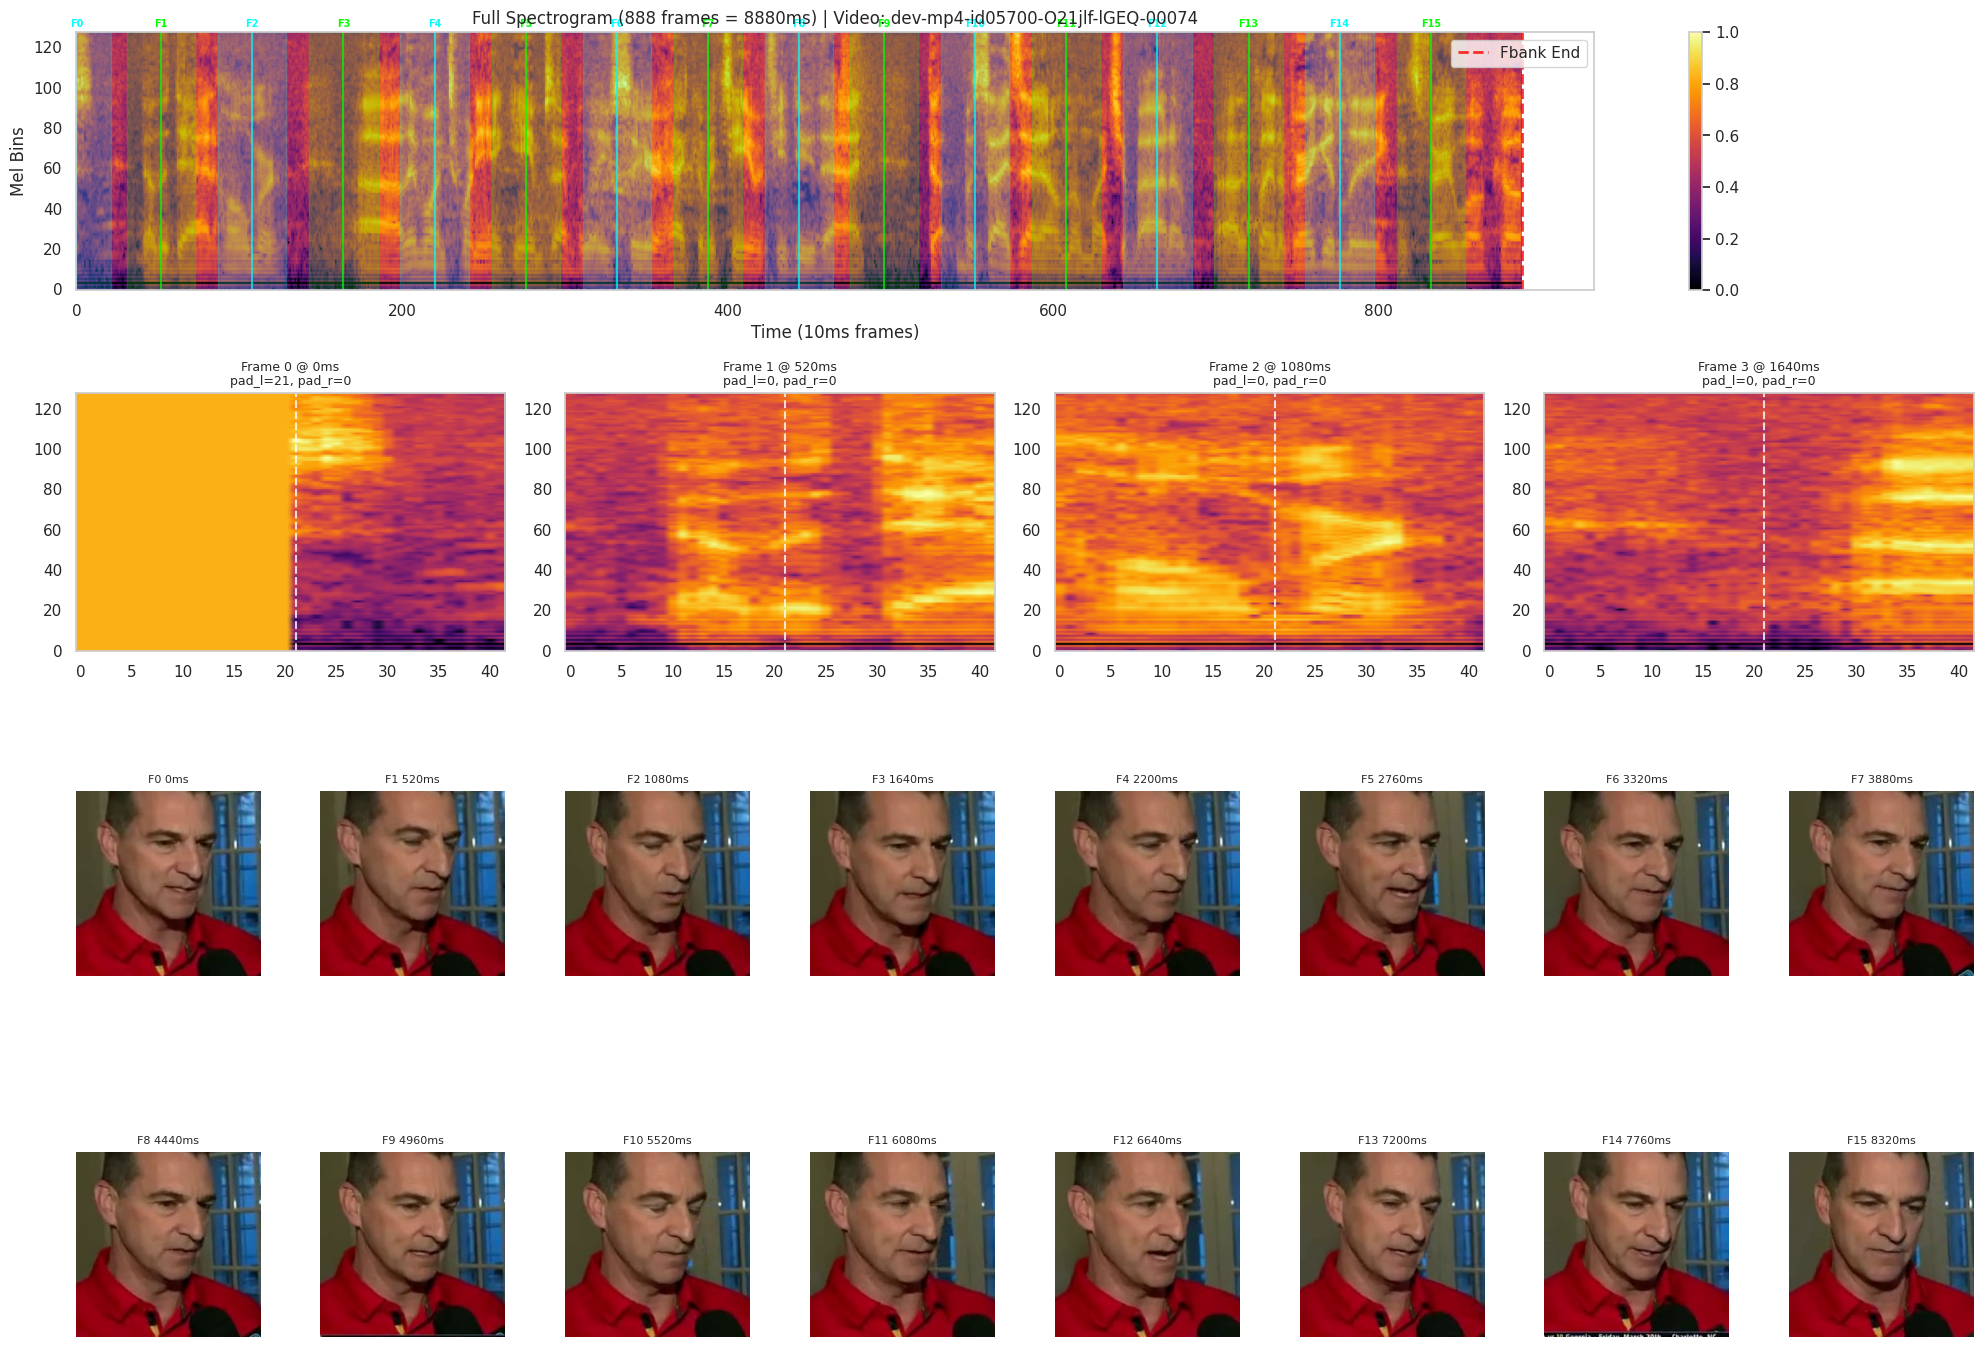


--- Timestamp Info ---
Frame  0: idx=  0, ts=    0.0ms, center=   0, pad_l=21, pad_r=0
Frame  1: idx= 13, ts=  520.0ms, center=  52, pad_l=0, pad_r=0
Frame  2: idx= 27, ts= 1080.0ms, center= 108, pad_l=0, pad_r=0
Frame  3: idx= 41, ts= 1640.0ms, center= 164, pad_l=0, pad_r=0
Frame  4: idx= 55, ts= 2200.0ms, center= 220, pad_l=0, pad_r=0
Frame  5: idx= 69, ts= 2760.0ms, center= 276, pad_l=0, pad_r=0
Frame  6: idx= 83, ts= 3320.0ms, center= 332, pad_l=0, pad_r=0
Frame  7: idx= 97, ts= 3880.0ms, center= 388, pad_l=0, pad_r=0
Frame  8: idx=111, ts= 4440.0ms, center= 444, pad_l=0, pad_r=0
Frame  9: idx=124, ts= 4960.0ms, center= 496, pad_l=0, pad_r=0
Frame 10: idx=138, ts= 5520.0ms, center= 552, pad_l=0, pad_r=0
Frame 11: idx=152, ts= 6080.0ms, center= 608, pad_l=0, pad_r=0
Frame 12: idx=166, ts= 6640.0ms, center= 664, pad_l=0, pad_r=0
Frame 13: idx=180, ts= 7200.0ms, center= 720, pad_l=0, pad_r=0
Frame 14: idx=194, ts= 7760.0ms, center= 776, pad_l=0, pad_r=0
Frame 15: idx=208, ts= 8320.0m

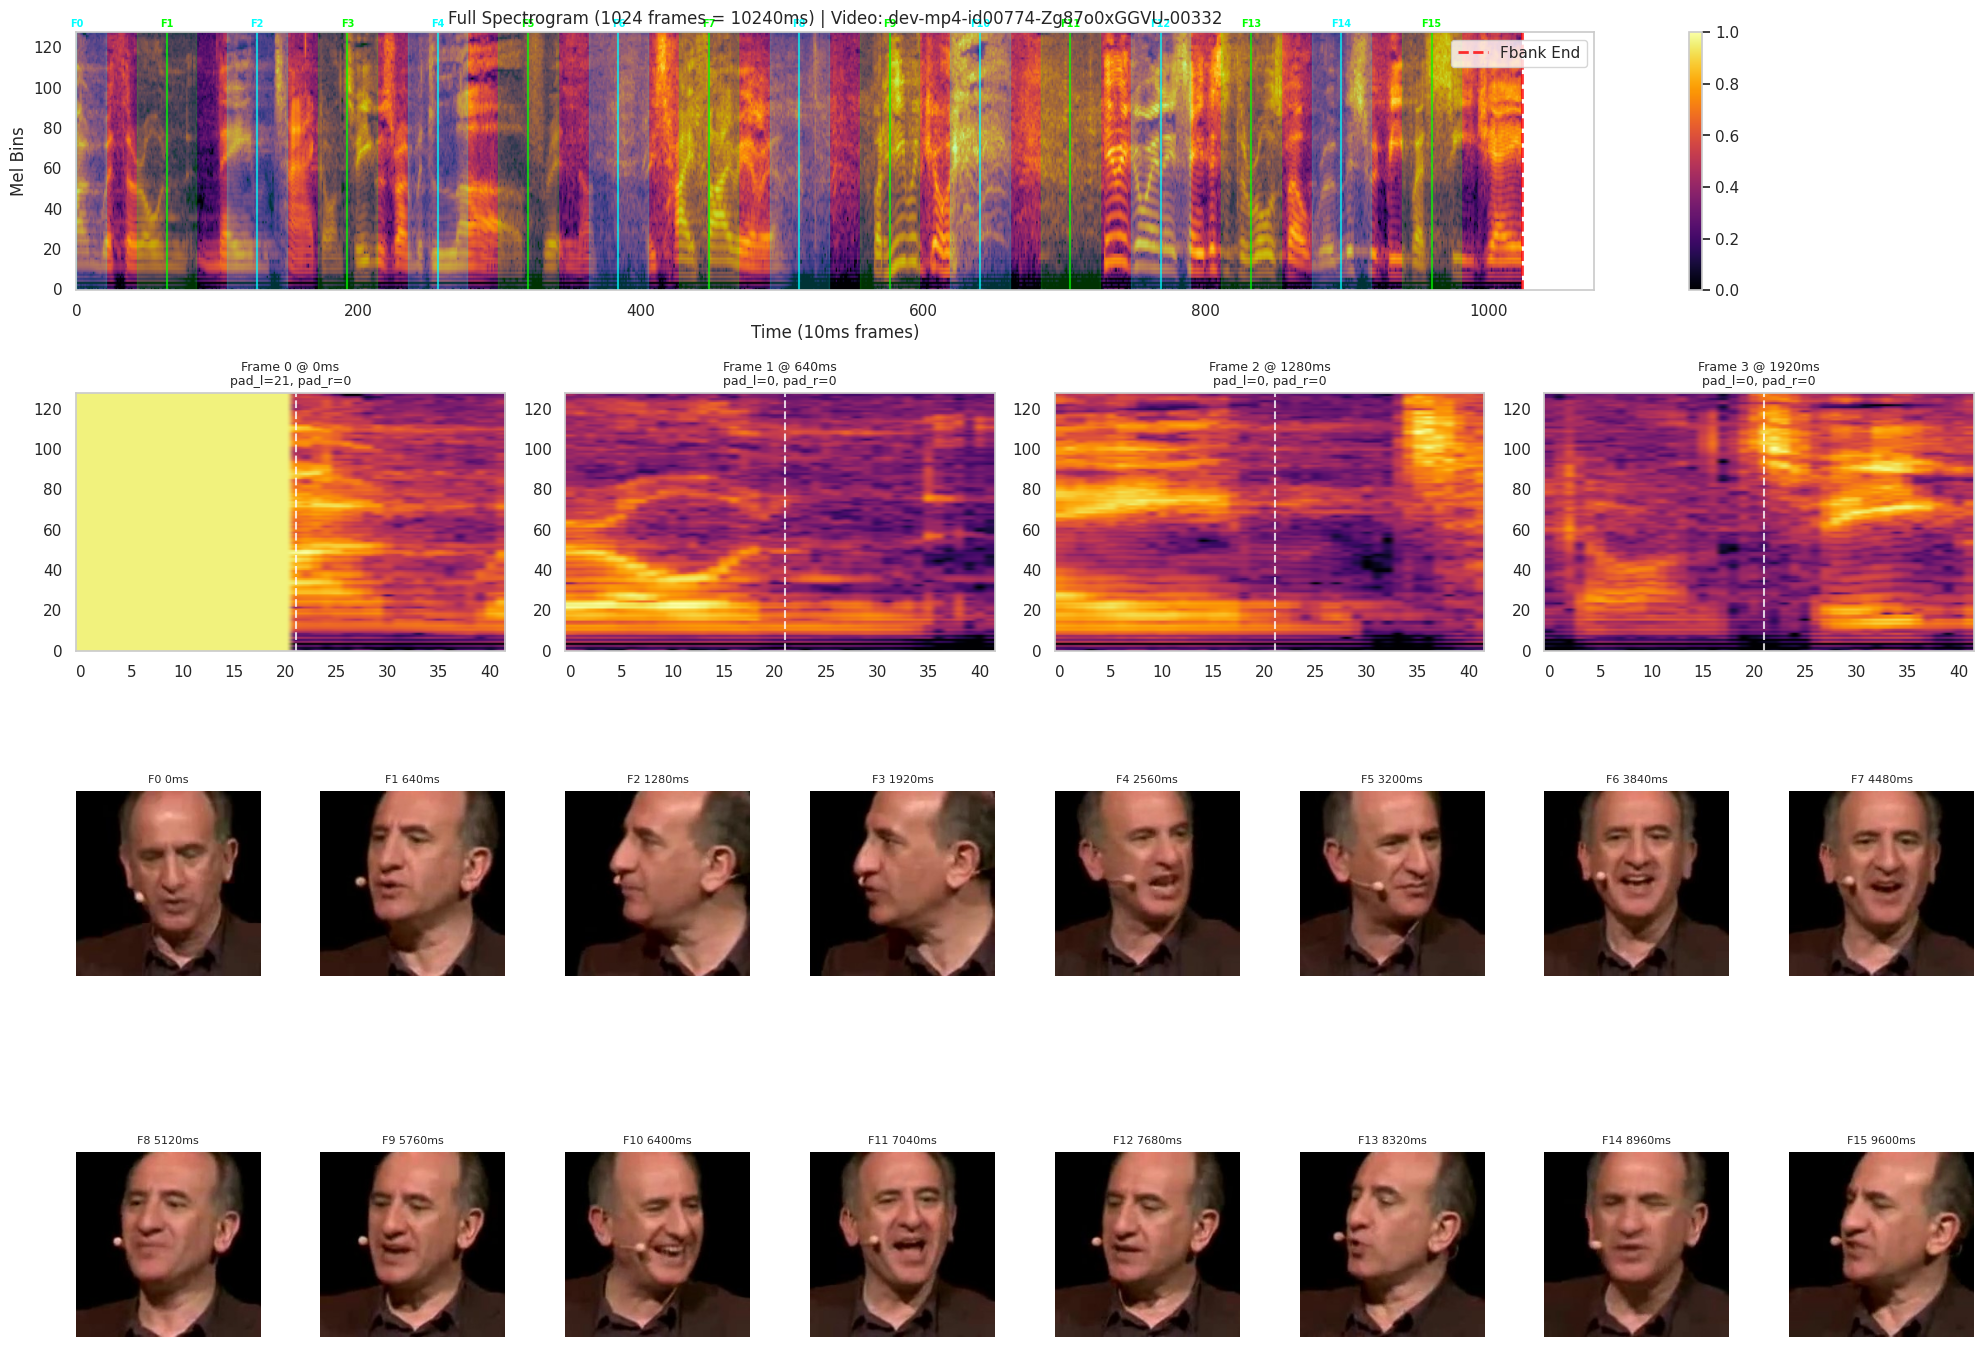


--- Timestamp Info ---
Frame  0: idx=  0, ts=    0.0ms, center=   0, pad_l=21, pad_r=0
Frame  1: idx= 16, ts=  640.0ms, center=  64, pad_l=0, pad_r=0
Frame  2: idx= 32, ts= 1280.0ms, center= 128, pad_l=0, pad_r=0
Frame  3: idx= 48, ts= 1920.0ms, center= 192, pad_l=0, pad_r=0
Frame  4: idx= 64, ts= 2560.0ms, center= 256, pad_l=0, pad_r=0
Frame  5: idx= 80, ts= 3200.0ms, center= 320, pad_l=0, pad_r=0
Frame  6: idx= 96, ts= 3840.0ms, center= 384, pad_l=0, pad_r=0
Frame  7: idx=112, ts= 4480.0ms, center= 448, pad_l=0, pad_r=0
Frame  8: idx=128, ts= 5120.0ms, center= 512, pad_l=0, pad_r=0
Frame  9: idx=144, ts= 5760.0ms, center= 576, pad_l=0, pad_r=0
Frame 10: idx=160, ts= 6400.0ms, center= 640, pad_l=0, pad_r=0
Frame 11: idx=176, ts= 7040.0ms, center= 704, pad_l=0, pad_r=0
Frame 12: idx=192, ts= 7680.0ms, center= 768, pad_l=0, pad_r=0
Frame 13: idx=208, ts= 8320.0ms, center= 832, pad_l=0, pad_r=0
Frame 14: idx=224, ts= 8960.0ms, center= 896, pad_l=0, pad_r=0
Frame 15: idx=240, ts= 9600.0m

In [48]:
# Visualize more samples
if data and len(data) > 1:
    for sample in random.sample(data, min(NUM_SAMPLES_VIZ, len(data))):
        visualize_with_timestamps(sample, TARGET_LENGTH)